# Sub-fase 4.2: Formalización del Marco Matemático (ULTRA)

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
import os
import json
import glob
from scipy.stats import pearsonr, spearmanr

# Style and Seed
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

# Paths
FIGURES_DIR = "phase4_figures"
TABLES_DIR = "phase4_tables"
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)

# Inputs
# PHASE3_CSV = "../../data/Phase3_Final/phase3_finalresults.csv" # Replaced by generator
PHASE3_CSV = 'C:/Users/emore/TFG/LISBETH-main/LISBETH-main/data/Phase3_Final/phase3_finalresults.csv'
# ANCHORS_CSV = "../../data/Phase3_Final/artifacts/embeddings_anchors.csv" # Replaced by generator
ANCHORS_CSV = 'C:/Users/emore/TFG/LISBETH-main/LISBETH-main/data/Phase3_Final/artifacts/embeddings_anchors.csv'
# ARTIFACTS_DIR = "../../data/Phase3_Final/artifacts" # Replaced by generator
ARTIFACTS_DIR = 'C:/Users/emore/TFG/LISBETH-main/LISBETH-main/data/Phase3_Final/artifacts'
# DIMENSIONS_JSON = "C:/Users/emore/TFG/LISBETH-main/LISBETH-main/data/dimensiones_ancla_conflicto.json" # Replaced by generator
DIMENSIONS_JSON = ''

print("Setup Complete. SEED=42.")


Setup Complete. SEED=42.


In [2]:

# Load Data
try:
    df = pd.read_csv(PHASE3_CSV)
    df['window_end_month'] = pd.to_datetime(df['window_end_month'])
    df.sort_values('window_end_month', inplace=True)
    print(f"Loaded Phase 3 Results: {len(df)} rows")
except Exception as e:
    print(f"CRITICAL FAIL: Could not load {PHASE3_CSV}")
    raise e

# Helpers
variants = ["baseline"]
if any("dapt" in c for c in df.columns):
    variants.append("dapt")
strategies = ["penultimate", "last4_concat"]

print(f"Variants: {variants}")
print(f"Strategies: {strategies}")


Loaded Phase 3 Results: 4 rows
Variants: ['baseline', 'dapt']
Strategies: ['penultimate', 'last4_concat']


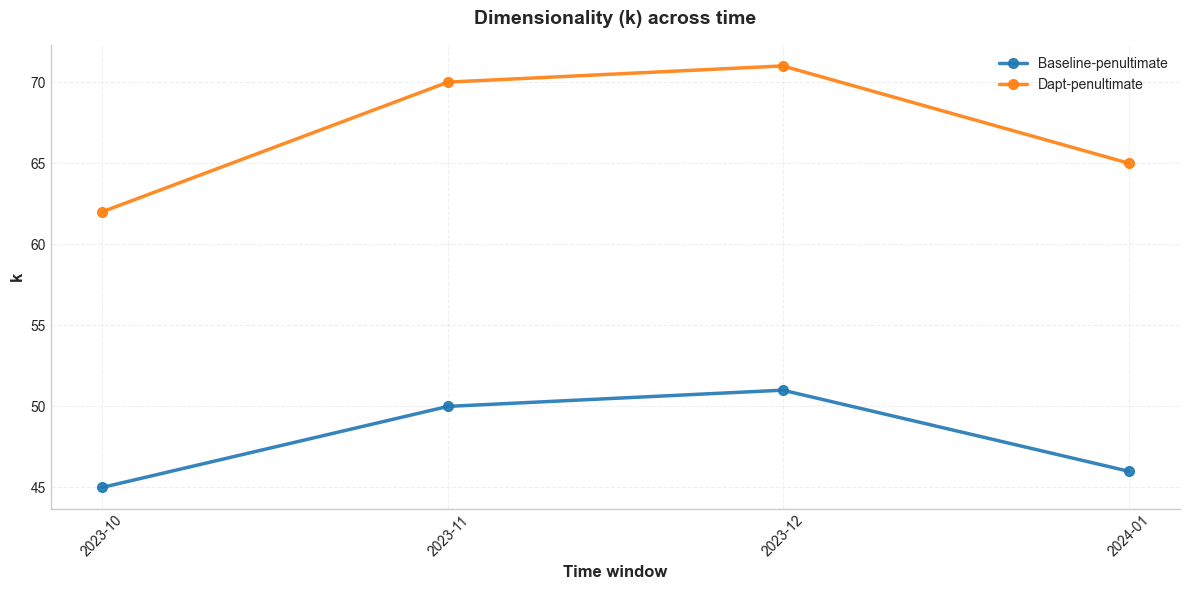

Correlation k vs n_occurrences (baseline): 0.989
Correlation k vs n_occurrences (dapt): 0.971


In [3]:
# --- 1. K Profile (Dimensionality) ---
# --- 1. K Profile (Dimensionality) ---

k_stats_list = []

variant_colors = {
    "baseline": "#1f77b4",
    "dapt": "#ff7f0e"
}

# A. K Distribution & Stability
plt.figure(figsize=(12, 6))

for v in variants:
    for s in strategies:
        col = f"k_{v}_{s}"
        if col in df.columns:
            desc = df[col].describe()
            delta_k = df[col].diff().abs()
            unstable_wins = (delta_k >= 3).sum()
            
            k_stats_list.append({
                "variant": v, 
                "strategy": s,
                "mean": desc['mean'], 
                "std": desc['std'],
                "min": desc['min'], 
                "max": desc['max'],
                "iqr": desc['75%'] - desc['25%'],
                "unstable_windows_delta_ge_3": unstable_wins
            })
            
            plt.plot(
                df['window_end_month'],
                df[col],
                marker='o',
                linewidth=2.5,
                markersize=7,
                alpha=0.9,
                color=variant_colors.get(v, "#333333"),
                label=f"{v.capitalize()}-{s}"
            )

plt.title(
    'Dimensionality (k) across time',
    fontsize=14,
    fontweight='bold',
    pad=15
)
plt.ylabel('k', fontsize=12, fontweight='bold')
plt.xlabel('Time window', fontsize=12, fontweight='bold')
plt.legend(frameon=False)
plt.grid(True, linestyle='--', alpha=0.3)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='both', labelsize=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/42_k_over_time.png", bbox_inches='tight', dpi=300)
plt.show()

pd.DataFrame(k_stats_list).to_csv(f"{TABLES_DIR}/42_k_profile.csv", index=False)

# B. K vs n_occurrences (Sensitivity)
# Check correlation
for v in variants:
    # Use one strategy for clarity, e.g., penultimate
    col = f"k_{v}_penultimate"
    if col in df.columns:
        corr, _ = pearsonr(df['n_occurrences'], df[col])
        print(f"Correlation k vs n_occurrences ({v}): {corr:.3f}")


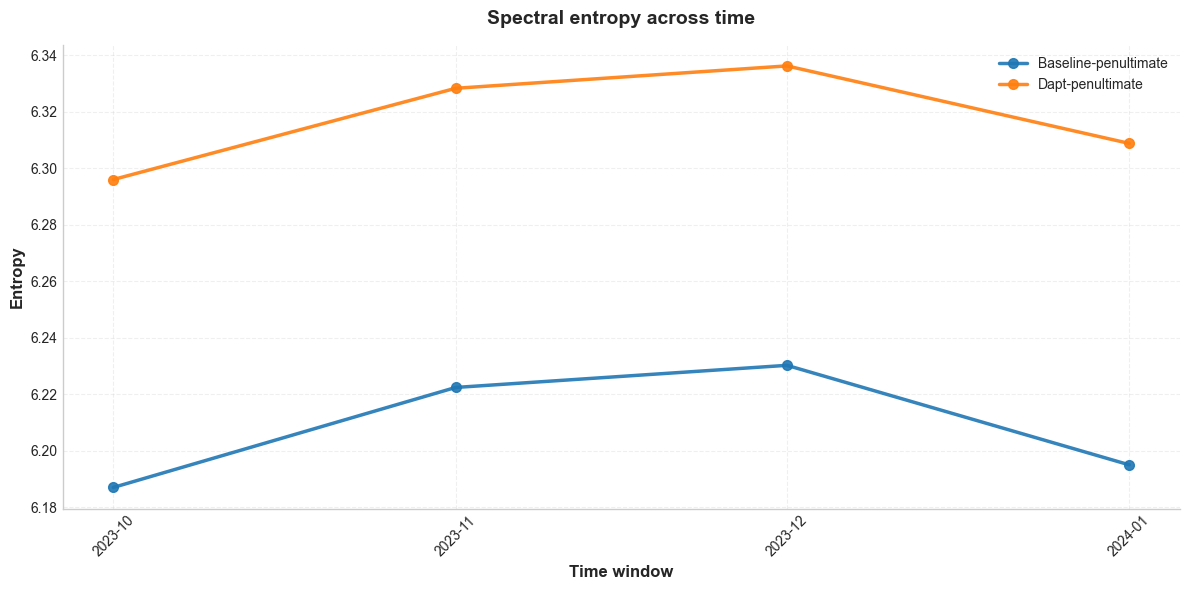

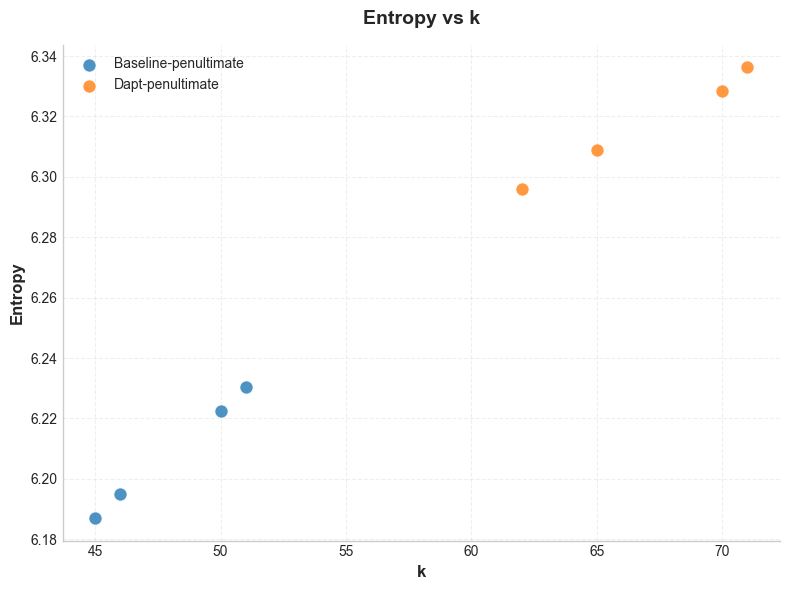

In [4]:
# --- 2. Entropy Analysis ---

ent_stats_list = []
ent_k_corr_list = []

# A. Entropy over Time
plt.figure(figsize=(12, 6))

for v in variants:
    for s in strategies:
        col = f"entropy_{v}_{s}"
        if col in df.columns:
            desc = df[col].describe()
            ent_stats_list.append({
                "variant": v,
                "strategy": s,
                "mean": desc['mean'],
                "std": desc['std']
            })

            plt.plot(
                df['window_end_month'],
                df[col],
                marker='o',
                linewidth=2.5,
                markersize=7,
                alpha=0.9,
                color=variant_colors.get(v, "#333333"),
                label=f"{v.capitalize()}-{s}"
            )

plt.title(
    'Spectral entropy across time',
    fontsize=14,
    fontweight='bold',
    pad=15
)
plt.xlabel('Time window', fontsize=12, fontweight='bold')
plt.ylabel('Entropy', fontsize=12, fontweight='bold')
plt.legend(frameon=False)
plt.grid(True, linestyle='--', alpha=0.3)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='both', labelsize=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/42_entropy_over_time.png", bbox_inches='tight', dpi=300)
plt.show()

pd.DataFrame(ent_stats_list).to_csv(f"{TABLES_DIR}/42_entropy_profile.csv", index=False)

# B. Entropy vs K (Scatter & Correlation)
plt.figure(figsize=(8, 6))

for v in variants:
    for s in strategies:
        k_col = f"k_{v}_{s}"
        e_col = f"entropy_{v}_{s}"

        if k_col in df.columns and e_col in df.columns:
            plt.scatter(
                df[k_col],
                df[e_col],
                label=f"{v.capitalize()}-{s}",
                alpha=0.8,
                s=90,
                color=variant_colors.get(v, "#333333"),
                edgecolor='white',
                linewidth=0.7
            )
            
            sub = df[[k_col, e_col]].dropna()
            corr_p, _ = pearsonr(sub[k_col], sub[e_col])
            corr_s, _ = spearmanr(sub[k_col], sub[e_col])
            
            ent_k_corr_list.append({
                "variant": v,
                "strategy": s,
                "pearson": corr_p,
                "spearman": corr_s
            })

plt.title(
    'Entropy vs k',
    fontsize=14,
    fontweight='bold',
    pad=15
)
plt.xlabel('k', fontsize=12, fontweight='bold')
plt.ylabel('Entropy', fontsize=12, fontweight='bold')
plt.legend(frameon=False)
plt.grid(True, linestyle='--', alpha=0.3)

ax = plt.gca()
ax.tick_params(axis='both', labelsize=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/42_entropy_vs_k.png", bbox_inches='tight', dpi=300)
plt.show()

pd.DataFrame(ent_k_corr_list).to_csv(f"{TABLES_DIR}/42_entropy_vs_k.csv", index=False)

# Sensitivity check
# entropy vs n_occurrences scatter?


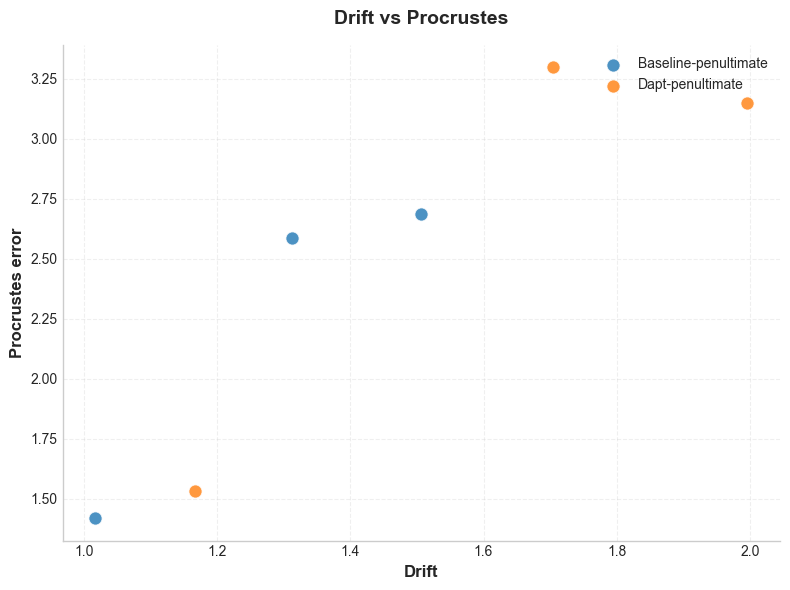

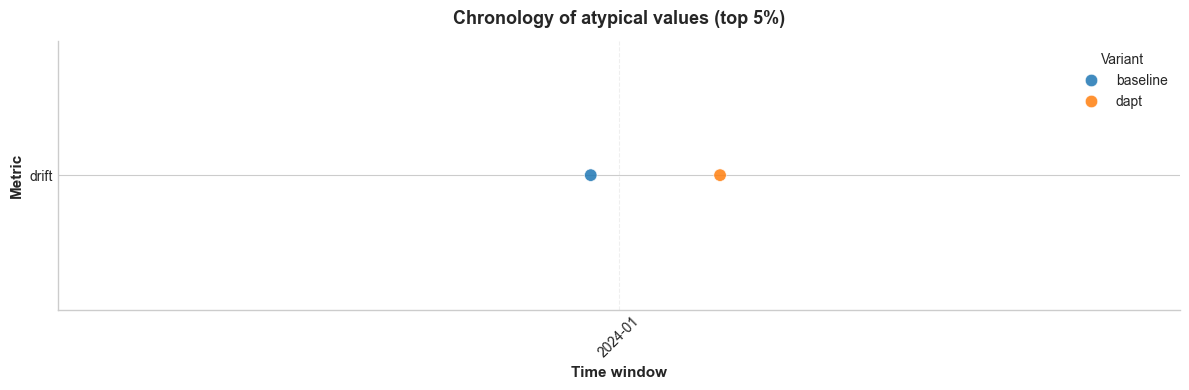

In [5]:
# --- 3. Drift & Procrustes (Detailed) ---
import matplotlib.dates as mdates

dp_profile = []
outliers_list = []

variant_colors = {
    "baseline": "#1f77b4",
    "dapt": "#ff7f0e"
}

# A. Combined Timelines
fig, ax = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

for v in variants:
    for s in strategies:
        d_col = f"drift_{v}_{s}"
        p_col = f"procrustes_{v}_{s}"
        
        if d_col in df.columns:
            ax[0].plot(
                df['window_end_month'],
                df[d_col],
                label=f"{v.capitalize()}-{s}",
                color=variant_colors.get(v, "#333333"),
                marker='o',
                linewidth=2.5,
                markersize=7,
                alpha=0.9
            )
            
            lim_d = df[d_col].quantile(0.95)
            outs = df[df[d_col] > lim_d].copy()
            if not outs.empty:
                outs['metric'] = 'drift'
                outs['variant'] = v
                outs['strategy'] = s
                outs['value'] = outs[d_col]
                outliers_list.append(
                    outs[['window_end_month', 'metric', 'variant', 'strategy', 'value']]
                )

        if p_col in df.columns:
            ax[1].plot(
                df['window_end_month'],
                df[p_col],
                label=f"{v.capitalize()}-{s}",
                color=variant_colors.get(v, "#333333"),
                marker='o',
                linewidth=2.5,
                markersize=7,
                alpha=0.9
            )

ax[0].set_title('Drift (Grassmann) across time', fontsize=13, fontweight='bold', pad=12)
ax[0].set_ylabel('Drift', fontsize=11, fontweight='bold')
ax[0].legend(frameon=False)
ax[0].grid(True, linestyle='--', alpha=0.3)

ax[1].set_title('Procrustes error across time', fontsize=13, fontweight='bold', pad=12)
ax[1].set_ylabel('Procrustes error', fontsize=11, fontweight='bold')
ax[1].set_xlabel('Time window', fontsize=11, fontweight='bold')
ax[1].legend(frameon=False)
ax[1].grid(True, linestyle='--', alpha=0.3)

ax[1].xaxis.set_major_locator(mdates.MonthLocator())
ax[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

for a in ax:
    a.tick_params(axis='both', labelsize=10)
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/42_drift_procrustes_combined.png", bbox_inches='tight', dpi=300)
plt.close()

# Separate Drift Plot
plt.figure(figsize=(10, 5))

for v in variants:
    for s in strategies:
        d_col = f"drift_{v}_{s}"
        if d_col in df.columns:
            plt.plot(
                df['window_end_month'],
                df[d_col],
                label=f"{v.capitalize()}-{s}",
                color=variant_colors.get(v, "#333333"),
                marker='o',
                linewidth=2.5,
                markersize=7,
                alpha=0.9
            )

plt.title("Drift across time", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Time window", fontsize=11, fontweight='bold')
plt.ylabel("Drift", fontsize=11, fontweight='bold')
plt.legend(frameon=False)
plt.grid(True, linestyle='--', alpha=0.3)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='both', labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/42_drift_over_time.png", bbox_inches='tight', dpi=300)
plt.close()

# Separate Procrustes Plot
plt.figure(figsize=(10, 5))

for v in variants:
    for s in strategies:
        p_col = f"procrustes_{v}_{s}"
        if p_col in df.columns:
            plt.plot(
                df['window_end_month'],
                df[p_col],
                label=f"{v.capitalize()}-{s}",
                color=variant_colors.get(v, "#333333"),
                marker='o',
                linewidth=2.5,
                markersize=7,
                alpha=0.9
            )

plt.title("Procrustes error across time", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Time window", fontsize=11, fontweight='bold')
plt.ylabel("Procrustes error", fontsize=11, fontweight='bold')
plt.legend(frameon=False)
plt.grid(True, linestyle='--', alpha=0.3)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='both', labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/42_procrustes_over_time.png", bbox_inches='tight', dpi=300)
plt.close()

# B. Drift vs Procrustes
# B. Drift vs Procrustes
plt.figure(figsize=(8, 6))

for v in variants:
    for s in strategies:
        d_col = f"drift_{v}_{s}"
        p_col = f"procrustes_{v}_{s}"

        if d_col in df.columns and p_col in df.columns:
            plt.scatter(
                df[d_col],
                df[p_col],
                label=f"{v.capitalize()}-{s}",
                alpha=0.8,
                s=90,
                color=variant_colors.get(v, "#333333"),
                edgecolor='white',
                linewidth=0.7
            )
            
            sub = df[[d_col, p_col]].dropna()
            if len(sub) > 2:
                corr, _ = pearsonr(sub[d_col], sub[p_col])
                dp_profile.append({
                    "variant": v,
                    "strategy": s,
                    "corr_drift_procrustes": corr,
                    "mean_drift": sub[d_col].mean(),
                    "mean_procrustes": sub[p_col].mean()
                })

plt.title('Drift vs Procrustes', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Drift', fontsize=12, fontweight='bold')
plt.ylabel('Procrustes error', fontsize=12, fontweight='bold')
plt.legend(frameon=False)
plt.grid(True, linestyle='--', alpha=0.3)

ax = plt.gca()
ax.tick_params(axis='both', labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/42_drift_vs_procrustes.png", bbox_inches='tight', dpi=300)
plt.show()


# C. Outliers Timeline
# C. Outliers Timeline
if outliers_list:
    outlier_df = pd.concat(outliers_list)
    outlier_df.to_csv(f"{TABLES_DIR}/42_outlier_windows.csv", index=False)

    outlier_df['window_label'] = pd.to_datetime(
        outlier_df['window_end_month']
    ).dt.strftime('%Y-%m')

    variant_colors = {
        "baseline": "#1f77b4",
        "dapt": "#ff7f0e"
    }

    plt.figure(figsize=(12, 4))

    sns.stripplot(
        data=outlier_df,
        x='window_label',
        y='metric',
        hue='variant',
        jitter=True,
        size=9,
        palette=variant_colors,
        alpha=0.85,
        edgecolor='white',
        linewidth=0.5
    )

    plt.title(
        'Chronology of atypical values (top 5%)',
        fontsize=13,
        fontweight='bold',
        pad=12
    )

    plt.xlabel('Time window', fontsize=11, fontweight='bold')
    plt.ylabel('Metric', fontsize=11, fontweight='bold')

    plt.grid(True, axis='x', linestyle='--', alpha=0.3)

    ax = plt.gca()
    ax.tick_params(axis='both', labelsize=10)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.xticks(rotation=45)

    plt.legend(title="Variant", frameon=False)

    plt.tight_layout()
    plt.savefig(
        f"{FIGURES_DIR}/42_outliers_timeline.png",
        bbox_inches='tight',
        dpi=300
    )
    plt.show()

pd.DataFrame(dp_profile).to_csv(
    f"{TABLES_DIR}/42_drift_procrustes_profile.csv",
    index=False
)

pd.DataFrame(dp_profile).to_csv(f"{TABLES_DIR}/42_drift_procrustes_profile.csv", index=False)


In [6]:
# --- 4. Geometría de Subespacios (Checks) ---

subspace_checks = []

# Randomly sample windows to check (or check all if manageable)
# Check 5 random windows per combination
sample_df = df.sample(min(5, len(df)))

for _, row in sample_df.iterrows():
    win_date = row['window_end_month'].strftime("%Y-%m")
    
    for v in variants:
        for s in strategies:
            # Construct path
            # Expected: window_YYYY-MM_variant_strategy.npz in artifacts/subspaces/
            # Or root artifacts dir
            fname = f"window_{win_date}_{v}_{s}.npz"
            paths = [
                f"{ARTIFACTS_DIR}/subspaces/{fname}",
                f"{ARTIFACTS_DIR}/{fname}"
            ]
            found = False
            for p in paths:
                if os.path.exists(p):
                    found = True
                    try:
                        data = np.load(p)
                        U = data['U']
                        # Check Orthonormality
                        UTU = U.T @ U
                        I = np.eye(UTU.shape[0])
                        err = np.linalg.norm(UTU - I, ord='fro')
                        
                        subspace_checks.append({
                            "window": win_date,
                            "variant": v,
                            "strategy": s,
                            "U_shape": str(U.shape),
                            "orthonormality_error": err,
                            "status": "PASS" if err < 1e-4 else "WARNING"
                        })
                    except Exception as e:
                        subspace_checks.append({"window": win_date, "variant": v, "status": "FAIL", "error": str(e)})
                    break
            if not found:
                pass # Silent skip if not found? Or mark missing?
                # subspace_checks.append({"window": win_date, "variant": v, "status": "MISSING"})

if subspace_checks:
    checks_df = pd.DataFrame(subspace_checks)
    checks_df.to_csv(f"{TABLES_DIR}/42_subspace_geometry_checks.csv", index=False)
    
    # Plot error
    plt.figure(figsize=(8, 5))
    sns.stripplot(data=checks_df, x='strategy', y='orthonormality_error', hue='variant')
    plt.title('Orthonormal error of the subspace (Frobenius)')
    plt.xlabel('Strategy')
    plt.ylabel('Orthonormality error')
    plt.yscale('log')
    plt.savefig(f"{FIGURES_DIR}/42_subspace_orthonormality.png")
    plt.show()
else:
    print("No subspace .npz files found to check.")


No subspace .npz files found to check.


In [7]:
# --- 5. Geometría de Anclas (Comparativa A/B) ---

anchor_checks = []
anchor_matrices = {} # Key: "{v}_{s}_{cond}"

conditions = ["raw", "corrected"]

for v in variants:
    for s in strategies:
        for cond in conditions:
            # File naming: anchors_{v}_{s}_{cond}.npz
            # (Note: dual_anisotropy_update.py saved them with suffixes _raw and _corrected)
            fname = f"anchors_{v}_{s}_{cond}.npz"
            paths = [
                f"{ARTIFACTS_DIR}/anchors/{fname}",
                f"{ARTIFACTS_DIR}/{fname}"
            ]
            
            found = False
            for p in paths:
                if os.path.exists(p):
                    found = True
                    try:
                        data = np.load(p)
                        A = data['A']
                        key = f"{v}_{s}_{cond}"
                        anchor_matrices[key] = A
                        
                        # Orthogonality
                        ATA = A.T @ A
                        I = np.eye(ATA.shape[0])
                        err = np.linalg.norm(ATA - I, ord='fro')
                        
                        # Off-diagonals (Max Cosine)
                        off_diag = ATA - np.diag(np.diag(ATA))
                        max_cos = np.max(np.abs(off_diag))
                        
                        anchor_checks.append({
                            "variant": v,
                            "strategy": s,
                            "condition": cond,
                            "orthogonality_error": err,
                            "max_cosine": max_cos
                        })
                        
                    except Exception as e:
                        print(f"Error loading {fname}: {e}")
                    break

pd.DataFrame(anchor_checks).to_csv(f"{TABLES_DIR}/42_anchor_geometry_checks_dual.csv", index=False)

# Visualizing Orthogonality (Heatmaps Side-by-Side)
keys = sorted(anchor_matrices.keys())
n = len(keys)
if n > 0:
    rows = len(variants) * len(strategies)
    cols = 2 # Raw vs Corrected
    fig, axes = plt.subplots(rows, cols, figsize=(10, 4*rows))
    axes = axes.flatten()

    # Etiquetas SOLO para visualización (no cambian claves, rutas ni nombres de archivos)
    variant_label = {
        "baseline": "Baseline",
        "dapt": "DAPT"
    }
    strategy_label = {
        "penultimate": "Penultimate",
        "last4_concat": "Last4Concat"
    }
    condition_label = {
        "raw": "No correction",
        "corrected": "Corrected"
    }
    
    idx = 0
    for v in variants:
        for s in strategies:
            v_lbl = variant_label.get(v, v)
            s_lbl = strategy_label.get(s, s)

            # Plot Raw
            k_raw = f"{v}_{s}_raw"
            ax_raw = axes[idx]
            if k_raw in anchor_matrices:
                 A = anchor_matrices[k_raw]
                 sns.heatmap(A.T @ A, annot=True, center=0, ax=ax_raw, cbar=False, cmap="RdBu_r", vmin=-1, vmax=1)
                 ax_raw.set_title(f"{v_lbl} · {s_lbl} · {condition_label['raw']}")
            idx += 1
            
            # Plot Corrected
            k_corr = f"{v}_{s}_corrected"
            ax_corr = axes[idx]
            if k_corr in anchor_matrices:
                 A = anchor_matrices[k_corr]
                 sns.heatmap(A.T @ A, annot=True, center=0, ax=ax_corr, cbar=False, cmap="RdBu_r", vmin=-1, vmax=1)
                 ax_corr.set_title(f"{v_lbl} · {s_lbl} · {condition_label['corrected']}")
            idx += 1
            
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/42_anchor_orthogonality_dual.png")
    plt.show()


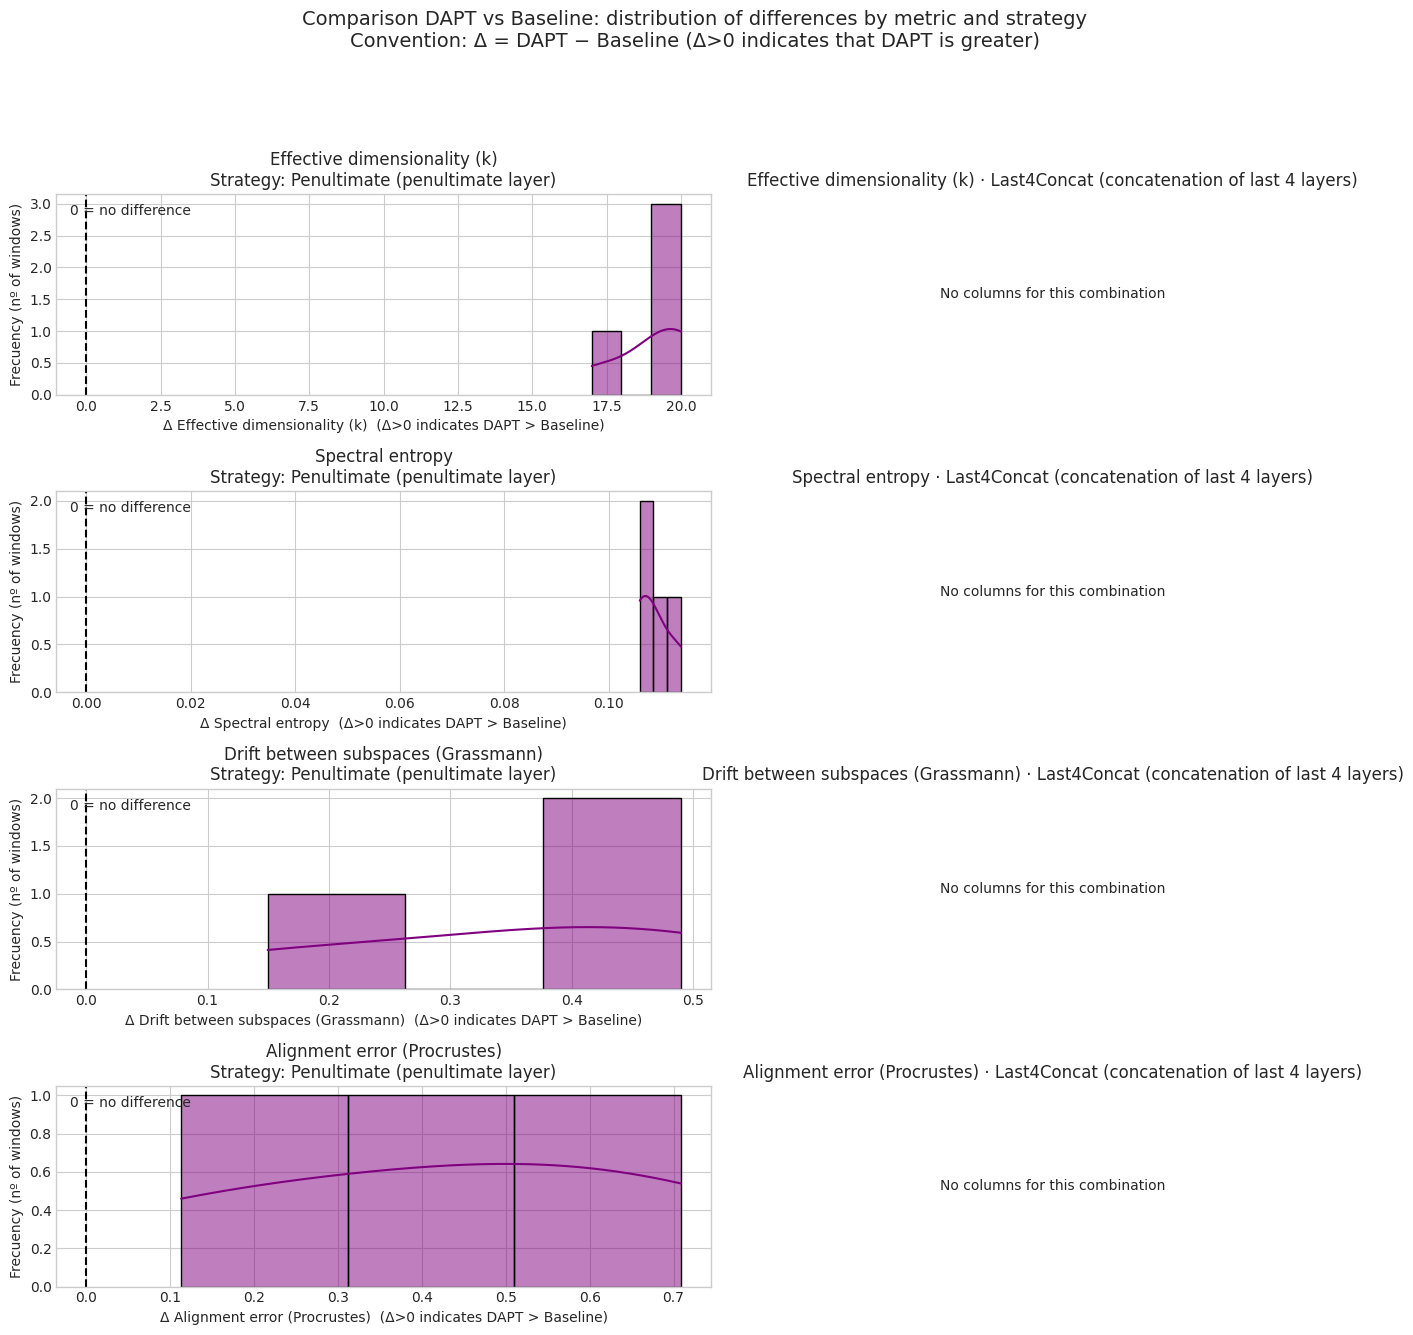

In [8]:
# --- 6. Baseline vs DAPT (Comparativa cuantitativa, Penultimate + Last4Concat) ---

import matplotlib as mpl
mpl.rcParams['font.family'] = 'DejaVu Sans'  # buena cobertura Unicode

if "dapt" in variants:
    metrics = ['k', 'entropy', 'drift', 'procrustes']
    strategies_to_plot = ['penultimate', 'last4_concat']

    deltas_list = []

    metric_label_es = {
        "k": "Effective dimensionality (k)",
        "entropy": "Spectral entropy",
        "drift": "Drift between subspaces (Grassmann)",
        "procrustes": "Alignment error (Procrustes)"
    }
    strategy_label_es = {
        "penultimate": "Penultimate (penultimate layer)",
        "last4_concat": "Last4Concat (concatenation of last 4 layers)"
    }

    # Fig setup: 4 métricas x 2 estrategias
    fig, axes = plt.subplots(len(metrics), len(strategies_to_plot), figsize=(14, 14), sharex=False)
    # Asegura indexación consistente si axes no es 2D (por si acaso)
    if len(metrics) == 1:
        axes = np.array([axes])

    fig.suptitle(
        "Comparison DAPT vs Baseline: distribution of differences by metric and strategy\n"
        "Convention: Δ = DAPT − Baseline (Δ>0 indicates that DAPT is greater)",
        fontsize=14
    )

    for r, m in enumerate(metrics):
        for c, s in enumerate(strategies_to_plot):
            ax = axes[r, c]

            col_b = f"{m}_baseline_{s}"
            col_d = f"{m}_dapt_{s}"

            # Si faltan columnas, deja el panel informativo (mejor que petar silenciosamente)
            if not (col_b in df.columns and col_d in df.columns):
                m_lbl = metric_label_es.get(m, m)
                s_lbl = strategy_label_es.get(s, s)
                ax.set_title(f"{m_lbl} · {s_lbl}")
                ax.text(
                    0.5, 0.5,
                    "No columns for this combination",
                    ha="center", va="center", transform=ax.transAxes
                )
                ax.set_axis_off()
                continue

            # Delta por métrica y estrategia (guardamos con sufijo de estrategia para no pisar)
            delta_col = f"delta_{m}_{s}"
            df[delta_col] = df[col_d] - df[col_b]  # Δ = DAPT - Baseline

            # Plot
            sns.histplot(df[delta_col], kde=True, ax=ax, color='purple')

            m_lbl = metric_label_es.get(m, m)
            s_lbl = strategy_label_es.get(s, s)
            ax.set_title(f"{m_lbl}\nStrategy: {s_lbl}")
            ax.set_xlabel(f"Δ {m_lbl}  (Δ>0 indicates DAPT > Baseline)")
            ax.set_ylabel("Frecuency (nº of windows)")

            # Línea 0
            ax.axvline(0, color='k', linestyle='--')
            ax.text(
                0.02, 0.95, "0 = no difference",
                transform=ax.transAxes, ha='left', va='top'
            )

            # Test (Wilcoxon)
            from scipy.stats import wilcoxon
            valid = df[[col_b, col_d]].dropna()
            stat, pval = wilcoxon(valid[col_b], valid[col_d])

            deltas_list.append({
                "metric": m,
                "strategy": s,
                "mean_delta": df[delta_col].mean(),
                "wilcoxon_stat": stat,
                "p_value": pval,
                "significant": pval < 0.05
            })

    plt.tight_layout(rect=[0, 0.03, 1, 0.93])
    plt.savefig(f"{FIGURES_DIR}/42_baseline_vs_dapt_math.png")
    plt.show()

    pd.DataFrame(deltas_list).to_csv(f"{TABLES_DIR}/42_baseline_vs_dapt_math.csv", index=False)
else:
    print("DAPT not present, skipping comparison.")
